# LP vs PPO: So sánh VM Allocation theo từng Scenario (CORRECTED - Cost & Utilization)

So sánh hai phương pháp phân bổ VM trên **cùng kịch bản tối ưu hóa**:

| Scenario | LP | PPO |
|----------|-----|-----|
| **OVERLOAD** | Minimize Resource Overload | Minimize SLA Violations |
| **COST** | Minimize Operational Cost | Minimize Operational Cost |

## Tiêu chí so sánh (per-step)
1. **Tổng số máy ảo** sử dụng
2. **Tỷ lệ sử dụng tài nguyên** (CPU/Memory utilization - tính trên host + VM)
3. **Chi phí thuê vận hành VM** (tính đúng với steps liên tiếp)
4. **SLA Violations**

## Lưu ý về Cost Calculation
- **Steps liên tiếp**: Mỗi step = 30 giây = 30/3600 giờ
- **VM Cost**: `vm_cost_per_hour × (30/3600)` cho mỗi step (per-hour cost)
- **Switching Cost**: **One-time cost** mỗi lần switch VM (KHÔNG nhân với thời gian)
- **Total Cost** = Tổng VM cost (nhân với thời gian) + Tổng switching cost (one-time)

## Lưu ý về CPU/Memory Utilization
- **Tính trên tổng hệ thống** (Host + VM): `(Required / Allocated Total) × 100`
- **CPU Utilization** = `cpu_required_cores / cpu_allocated_cores × 100`
- **Memory Utilization** = `mem_required_gb / mem_allocated_gb × 100`
- `cpu_allocated_cores` và `mem_allocated_gb` đã bao gồm cả host và VM

## Output Files
- `lp_vs_ppo_comparison_corrected_overload.csv` - So sánh chi tiết cho scenario OVERLOAD
- `lp_vs_ppo_comparison_corrected_cost.csv` - So sánh chi tiết cho scenario COST
- Các files này chứa: timestamp, target fields, mem_required_gb, overflow values, allocations, và metrics cho cả LP và PPO


In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from rl.config import HOST_SPEC

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

RESULTS_DIR = Path('forecast_result')
print('✓ Libraries loaded')
print(f'✓ Host spec: {HOST_SPEC}')


✓ Libraries loaded
✓ Host spec: {'total_cpu_cores': 1, 'total_memory_gb': 4, 'cpu_threshold_pct': 70, 'memory_threshold_pct': 75}


## 1. Load dữ liệu từ LP và PPO


In [125]:
# Load test data với target fields và mem_required_gb
print("=== Loading Test Data (Target Fields) ===")
TEST_TARGETS_PATH = Path('processed_data/split_data/test_targets.csv')
if TEST_TARGETS_PATH.exists():
    test_targets_df = pd.read_csv(TEST_TARGETS_PATH)
    if 'datetime' in test_targets_df.columns:
        test_targets_df['datetime'] = pd.to_datetime(test_targets_df['datetime'])
    print(f'Test targets:       {len(test_targets_df):,} rows')
    print(f'  Columns: {list(test_targets_df.columns)}')
else:
    print(f'⚠️ Test targets not found at {TEST_TARGETS_PATH}')
    print('  Will use data from LP/PPO schedules only')
    test_targets_df = None

# Load LP schedules (BOTH scenarios) - Format mới giống PPO
lp_overload_path = RESULTS_DIR / 'lp_schedule_overload.csv'
lp_cost_path = RESULTS_DIR / 'lp_schedule_cost.csv'

print("\n=== Loading LP Schedules (New Format) ===")
if lp_overload_path.exists():
    lp_overload_df = pd.read_csv(lp_overload_path)
    lp_overload_df['timestamp'] = pd.to_datetime(lp_overload_df['timestamp'])
    print(f'LP (Overload):      {len(lp_overload_df):,} steps')
    print(f'  Columns: {list(lp_overload_df.columns)}')
else:
    print(f'⚠️ LP Overload not found. Run: vm_resource_planner.ipynb')
    lp_overload_df = None

if lp_cost_path.exists():
    lp_cost_df = pd.read_csv(lp_cost_path)
    lp_cost_df['timestamp'] = pd.to_datetime(lp_cost_df['timestamp'])
    print(f'LP (Cost):          {len(lp_cost_df):,} steps')
    print(f'  Columns: {list(lp_cost_df.columns)}')
else:
    print(f'⚠️ LP Cost not found. Run: vm_resource_planner.ipynb')
    lp_cost_df = None

# Load PPO schedules (both scenarios)
print("\n=== Loading PPO Schedules ===")
ppo_overload_df = pd.read_csv(RESULTS_DIR / 'ppo_schedule_test_overload.csv')
ppo_cost_df = pd.read_csv(RESULTS_DIR / 'ppo_schedule_test_cost.csv')
ppo_overload_df['timestamp'] = pd.to_datetime(ppo_overload_df['timestamp'])
ppo_cost_df['timestamp'] = pd.to_datetime(ppo_cost_df['timestamp'])
print(f'PPO (Overload):     {len(ppo_overload_df):,} steps')
print(f'PPO (Cost):         {len(ppo_cost_df):,} steps')

# Số steps để so sánh công bằng
n_steps = min(len(ppo_overload_df), len(ppo_cost_df))
if lp_overload_df is not None:
    n_steps = min(n_steps, len(lp_overload_df))
if lp_cost_df is not None:
    n_steps = min(n_steps, len(lp_cost_df))
print(f'\n→ So sánh trên {n_steps} steps đầu tiên')

# Cắt tất cả về cùng số steps
if lp_overload_df is not None:
    lp_overload_df = lp_overload_df.iloc[:n_steps].copy()
if lp_cost_df is not None:
    lp_cost_df = lp_cost_df.iloc[:n_steps].copy()
ppo_overload_df = ppo_overload_df.iloc[:n_steps].copy()
ppo_cost_df = ppo_cost_df.iloc[:n_steps].copy()
if test_targets_df is not None:
    test_targets_df = test_targets_df.iloc[:n_steps].copy()


=== Loading Test Data (Target Fields) ===
Test targets:       17,150 rows
  Columns: ['datetime', 'timestamp', 'memory_usage_pct', 'cpu_total_usage', 'system_load', 'mem_required_gb']

=== Loading LP Schedules (New Format) ===
LP (Overload):      17,150 steps
  Columns: ['timestamp', 'allocation', 'vm_cost_per_hour', 'switching_cost', 'total_cost_per_hour', 'cpu_allocated_cores', 'mem_allocated_gb', 'cpu_vm_only', 'mem_vm_only', 'cpu_required_cores', 'mem_required_gb', 'cpu_overflow_cores', 'mem_overflow_gb', 'cpu_utilization_pct', 'mem_utilization_pct', 'sla_violation_flag']
LP (Cost):          17,150 steps
  Columns: ['timestamp', 'allocation', 'vm_cost_per_hour', 'switching_cost', 'total_cost_per_hour', 'cpu_allocated_cores', 'mem_allocated_gb', 'cpu_vm_only', 'mem_vm_only', 'cpu_required_cores', 'mem_required_gb', 'cpu_overflow_cores', 'mem_overflow_gb', 'cpu_utilization_pct', 'mem_utilization_pct', 'sla_violation_flag']

=== Loading PPO Schedules ===
PPO (Overload):     17,150 ste

In [126]:
# Preview LP data (both scenarios) - Format mới giống PPO
print('=== LP Overload Schedule Preview (New Format) ===')
if lp_overload_df is not None:
    ppo_format_cols = [
        'timestamp', 'allocation', 'vm_cost_per_hour', 'switching_cost', 'total_cost_per_hour',
        'cpu_allocated_cores', 'mem_allocated_gb', 'cpu_vm_only', 'mem_vm_only',
        'cpu_required_cores', 'mem_required_gb', 'cpu_overflow_cores', 'mem_overflow_gb',
        'cpu_utilization_pct', 'mem_utilization_pct', 'sla_violation_flag'
    ]
    available_cols = [c for c in ppo_format_cols if c in lp_overload_df.columns]
    display(lp_overload_df[available_cols].head(5))

print('\n=== LP Cost Schedule Preview (New Format) ===')
if lp_cost_df is not None:
    available_cols = [c for c in ppo_format_cols if c in lp_cost_df.columns]
    display(lp_cost_df[available_cols].head(5))


=== LP Overload Schedule Preview (New Format) ===


,timestamp,allocation,vm_cost_per_hour,switching_cost,total_cost_per_hour,cpu_allocated_cores,mem_allocated_gb,cpu_vm_only,mem_vm_only,cpu_required_cores,mem_required_gb,cpu_overflow_cores,mem_overflow_gb,cpu_utilization_pct,mem_utilization_pct,sla_violation_flag
0,1970-01-25 01:05:30,Host only,0.0,0.0,0.0,0.7,3.0,0.0,0.0,0.24,0.258175,0.0,0.0,0.0,0.0,0
1,1970-01-25 01:06:00,Host only,0.0,0.0,0.0,0.7,3.0,0.0,0.0,0.22,0.258186,0.0,0.0,0.0,0.0,0
2,1970-01-25 01:06:30,Host only,0.0,0.0,0.0,0.7,3.0,0.0,0.0,0.13,0.258044,0.0,0.0,0.0,0.0,0
3,1970-01-25 01:07:00,Host only,0.0,0.0,0.0,0.7,3.0,0.0,0.0,0.08,0.257840,0.0,0.0,0.0,0.0,0
4,1970-01-25 01:07:30,Host only,0.0,0.0,0.0,0.7,3.0,0.0,0.0,0.10,0.258327,0.0,0.0,0.0,0.0,0



=== LP Cost Schedule Preview (New Format) ===


,timestamp,allocation,vm_cost_per_hour,switching_cost,total_cost_per_hour,cpu_allocated_cores,mem_allocated_gb,cpu_vm_only,mem_vm_only,cpu_required_cores,mem_required_gb,cpu_overflow_cores,mem_overflow_gb,cpu_utilization_pct,mem_utilization_pct,sla_violation_flag
0,1970-01-25 01:05:30,Host only,0.0,0.0,0.0,0.7,3.0,0.0,0.0,0.24,0.258175,0.0,0.0,0.0,0.0,0
1,1970-01-25 01:06:00,Host only,0.0,0.0,0.0,0.7,3.0,0.0,0.0,0.22,0.258186,0.0,0.0,0.0,0.0,0
2,1970-01-25 01:06:30,Host only,0.0,0.0,0.0,0.7,3.0,0.0,0.0,0.13,0.258044,0.0,0.0,0.0,0.0,0
3,1970-01-25 01:07:00,Host only,0.0,0.0,0.0,0.7,3.0,0.0,0.0,0.08,0.257840,0.0,0.0,0.0,0.0,0
4,1970-01-25 01:07:30,Host only,0.0,0.0,0.0,0.7,3.0,0.0,0.0,0.10,0.258327,0.0,0.0,0.0,0.0,0


In [127]:
# Preview PPO data (both scenarios)
print('=== PPO Overload Schedule Preview ===')
display(ppo_overload_df[['timestamp', 'allocation', 'vm_cost_per_hour', 
         'cpu_utilization_pct', 'sla_violation_flag']].head(5))

print('\n=== PPO Cost Schedule Preview ===')
display(ppo_cost_df[['timestamp', 'allocation', 'vm_cost_per_hour', 
         'cpu_utilization_pct', 'sla_violation_flag']].head(5))


=== PPO Overload Schedule Preview ===


,timestamp,allocation,vm_cost_per_hour,cpu_utilization_pct,sla_violation_flag
0,1970-01-25 01:05:30,Host only,0.0,0.0,0
1,1970-01-25 01:06:00,Host only,0.0,0.0,0
2,1970-01-25 01:06:30,Host only,0.0,0.0,0
3,1970-01-25 01:07:00,Host only,0.0,0.0,0
4,1970-01-25 01:07:30,Host only,0.0,0.0,0



=== PPO Cost Schedule Preview ===


,timestamp,allocation,vm_cost_per_hour,cpu_utilization_pct,sla_violation_flag
0,1970-01-25 01:05:30,Host only,0.0,0.0,0
1,1970-01-25 01:06:00,Host only,0.0,0.0,0
2,1970-01-25 01:06:30,Host only,0.0,0.0,0
3,1970-01-25 01:07:00,Host only,0.0,0.0,0
4,1970-01-25 01:07:30,Host only,0.0,0.0,0


## 2. Trích xuất & Tính toán Metrics


In [128]:
def extract_vm_count(allocation_str):
    """Trích xuất tổng số VM từ chuỗi allocation
    
    Format mới: 'B2s:2, D2s_v3:1' (sử dụng ':' separator)
    """
    if pd.isna(allocation_str) or allocation_str in ['Host only', 'No VMs']:
        return 0
    total = 0
    parts = str(allocation_str).split(',')
    for part in parts:
        part = part.strip()
        if ':' in part:
            try:
                count = int(part.split(':')[1])
                total += count
            except (ValueError, IndexError):
                pass
    return total

# Tính vm_count cho PPO
ppo_cost_df['vm_count'] = ppo_cost_df['allocation'].apply(extract_vm_count)
ppo_overload_df['vm_count'] = ppo_overload_df['allocation'].apply(extract_vm_count)

# Tính vm_count cho LP (format mới dùng ':' giống PPO)
if lp_overload_df is not None:
    lp_overload_df['vm_count'] = lp_overload_df['allocation'].apply(extract_vm_count)

if lp_cost_df is not None:
    lp_cost_df['vm_count'] = lp_cost_df['allocation'].apply(extract_vm_count)

print('✓ VM counts extracted for all methods (using : format)')


✓ VM counts extracted for all methods (using : format)


In [129]:
def compute_metrics(df, name, cost_col='total_cost_per_hour', 
                    cpu_col='cpu_utilization_pct', mem_col='mem_utilization_pct',
                    sla_col='sla_violation_flag'):
    """Tính metrics per-step cho một phương pháp (format mới giống PPO)
    
    Note: 
    - Steps are consecutive (30s each)
    - VM cost: per-hour cost, multiplied by 30/3600
    - Switching cost: one-time cost, NOT multiplied by time
    - CPU/Memory Utilization: calculated on total allocated (host + VM)
    """
    # Step duration: 30 seconds = 30/3600 hours = 1/120 hours
    STEP_DURATION_HOURS = 30 / 3600
    
    # Handle different column names for backward compatibility
    if cost_col not in df.columns and 'vm_cost_per_hour' in df.columns:
        cost_col = 'vm_cost_per_hour'
    if sla_col not in df.columns and 'sla_violation' in df.columns:
        sla_col = 'sla_violation'
    
    n = len(df)
    
    # 1. Tổng số VM
    total_vms = int(df['vm_count'].sum())
    avg_vms = df['vm_count'].mean()
    max_vms = int(df['vm_count'].max())
    steps_with_vms = int((df['vm_count'] > 0).sum())
    
    # 2. Tỷ lệ sử dụng tài nguyên (tính trên tổng hệ thống: host + VM)
    # CPU Utilization = (CPU required) / (CPU allocated total) × 100
    # Memory Utilization = (Memory required) / (Memory allocated total) × 100
    cpu_util = 0.0
    mem_util = 0.0
    cpu_util_host_only = 0.0
    mem_util_host_only = 0.0
    cpu_util_with_vm = 0.0
    mem_util_with_vm = 0.0
    
    # Tính host threshold từ HOST_SPEC
    host_cpu_threshold = HOST_SPEC["total_cpu_cores"] * HOST_SPEC["cpu_threshold_pct"] / 100.0
    host_mem_threshold = HOST_SPEC["total_memory_gb"] * HOST_SPEC["memory_threshold_pct"] / 100.0
    
    if 'cpu_required_cores' in df.columns and 'cpu_allocated_cores' in df.columns:
        # Tính utilization cho tất cả steps (không chỉ steps có VM)
        valid_cpu = df[(df['cpu_allocated_cores'] > 0) & (df['cpu_required_cores'] >= 0)]
        if len(valid_cpu) > 0:
            cpu_util = (valid_cpu['cpu_required_cores'] / valid_cpu['cpu_allocated_cores'] * 100).mean()
            cpu_util = min(100.0, max(0.0, cpu_util))  # Clamp 0-100
            
            # Tính riêng cho host-only và with-VM
            host_only_steps = valid_cpu[valid_cpu['vm_count'] == 0]
            with_vm_steps = valid_cpu[valid_cpu['vm_count'] > 0]
            
            if len(host_only_steps) > 0:
                cpu_util_host_only = (host_only_steps['cpu_required_cores'] / host_only_steps['cpu_allocated_cores'] * 100).mean()
                cpu_util_host_only = min(100.0, max(0.0, cpu_util_host_only))
            
            if len(with_vm_steps) > 0:
                cpu_util_with_vm = (with_vm_steps['cpu_required_cores'] / with_vm_steps['cpu_allocated_cores'] * 100).mean()
                cpu_util_with_vm = min(100.0, max(0.0, cpu_util_with_vm))
    
    if 'mem_required_gb' in df.columns and 'mem_allocated_gb' in df.columns:
        valid_mem = df[(df['mem_allocated_gb'] > 0) & (df['mem_required_gb'] >= 0)]
        if len(valid_mem) > 0:
            mem_util = (valid_mem['mem_required_gb'] / valid_mem['mem_allocated_gb'] * 100).mean()
            mem_util = min(100.0, max(0.0, mem_util))  # Clamp 0-100
            
            # Tính riêng cho host-only và with-VM
            host_only_steps = valid_mem[valid_mem['vm_count'] == 0]
            with_vm_steps = valid_mem[valid_mem['vm_count'] > 0]
            
            if len(host_only_steps) > 0:
                mem_util_host_only = (host_only_steps['mem_required_gb'] / host_only_steps['mem_allocated_gb'] * 100).mean()
                mem_util_host_only = min(100.0, max(0.0, mem_util_host_only))
            
            if len(with_vm_steps) > 0:
                mem_util_with_vm = (with_vm_steps['mem_required_gb'] / with_vm_steps['mem_allocated_gb'] * 100).mean()
                mem_util_with_vm = min(100.0, max(0.0, mem_util_with_vm))
    
    # 3. Chi phí vận hành
    # VM cost: per-hour cost, nhân với thời gian step
    # Switching cost: one-time cost, KHÔNG nhân với thời gian
    total_vm_cost = 0.0
    total_switching_cost = 0.0
    
    if 'vm_cost_per_hour' in df.columns:
        total_vm_cost = (df['vm_cost_per_hour'] * STEP_DURATION_HOURS).sum()
        avg_vm_cost_rate = df['vm_cost_per_hour'].mean()
    else:
        avg_vm_cost_rate = 0.0
    
    if 'switching_cost' in df.columns:
        # Switching cost là one-time cost, không nhân với thời gian
        total_switching_cost = df['switching_cost'].sum()
    else:
        total_switching_cost = 0.0
    
    total_cost = total_vm_cost + total_switching_cost
    
    # Avg cost rate (chỉ tính VM cost rate, không tính switching)
    avg_cost = avg_vm_cost_rate if 'vm_cost_per_hour' in df.columns else 0.0
    
    # SLA violations
    sla_violations = int(df[sla_col].sum()) if sla_col in df.columns else 0
    
    return {
        'Method': name,
        'Steps': n,
        'Total VMs': total_vms,
        'Avg VMs/Step': round(avg_vms, 3),
        'Max VMs': max_vms,
        'Steps with VMs': steps_with_vms,
        'CPU Util %': round(cpu_util, 2),  # Total system (host + VM)
        'Mem Util %': round(mem_util, 2),   # Total system (host + VM)
        'CPU Util % (Host Only)': round(cpu_util_host_only, 2),
        'CPU Util % (With VM)': round(cpu_util_with_vm, 2),
        'Mem Util % (Host Only)': round(mem_util_host_only, 2),
        'Mem Util % (With VM)': round(mem_util_with_vm, 2),
        'Total Cost ($)': round(total_cost, 4),  # VM cost (time-based) + Switching cost (one-time)
        'Total VM Cost ($)': round(total_vm_cost, 4),  # VM cost only
        'Total Switching Cost ($)': round(total_switching_cost, 4),  # Switching cost only
        'Avg Cost/Step ($/h)': round(avg_cost, 4),  # VM cost rate per step
        'SLA Violations': sla_violations,
    }

# Tính metrics theo TỪNG SCENARIO
metrics_overload = []
metrics_cost = []

# Scenario: OVERLOAD (LP vs PPO)
if lp_overload_df is not None:
    metrics_overload.append(compute_metrics(lp_overload_df, 'LP'))
metrics_overload.append(compute_metrics(ppo_overload_df, 'PPO'))

# Scenario: COST (LP vs PPO)
if lp_cost_df is not None:
    metrics_cost.append(compute_metrics(lp_cost_df, 'LP'))
metrics_cost.append(compute_metrics(ppo_cost_df, 'PPO'))

print(f'✓ Metrics computed for {n_steps} steps per scenario (with corrected cost calculation)')


✓ Metrics computed for 17150 steps per scenario (with corrected cost calculation)


## 3. Bảng So sánh theo Scenario


In [130]:
# Bảng so sánh cho SCENARIO: OVERLOAD
print("="*60)
print("    SCENARIO: OVERLOAD (Minimize Resource Overload)")
print("="*60)
if metrics_overload:
    df_overload = pd.DataFrame(metrics_overload).set_index('Method')
    display(df_overload.T)


    SCENARIO: OVERLOAD (Minimize Resource Overload)


Method,LP,PPO
Steps,17150.0000,17150.0000
Total VMs,394.0000,1752.0000
Avg VMs/Step,0.0230,0.1020
Max VMs,1.0000,19.0000
Steps with VMs,394.0000,389.0000
CPU Util %,18.3600,18.5900
Mem Util %,7.7500,7.7600
CPU Util % (Host Only),18.7100,18.7500
CPU Util % (With VM),3.6200,11.6000
Mem Util % (Host Only),7.9300,7.9300


In [131]:
# Bảng so sánh cho SCENARIO: COST
print("="*60)
print("    SCENARIO: COST (Minimize Operational Cost)")
print("="*60)
if metrics_cost:
    df_cost = pd.DataFrame(metrics_cost).set_index('Method')
    display(df_cost.T)


    SCENARIO: COST (Minimize Operational Cost)


Method,LP,PPO
Steps,17150.0000,17150.0000
Total VMs,394.0000,1193.0000
Avg VMs/Step,0.0230,0.0700
Max VMs,1.0000,16.0000
Steps with VMs,394.0000,220.0000
CPU Util %,19.2900,20.2300
Mem Util %,7.8300,7.8300
CPU Util % (Host Only),18.7100,20.2900
CPU Util % (With VM),43.8700,16.0100
Mem Util % (Host Only),7.9300,7.9200


## 4. Visualizations


In [132]:
# Color palette
COLORS = {
    'LP': '#2ecc71',    # Green
    'PPO': '#3498db',   # Blue
}


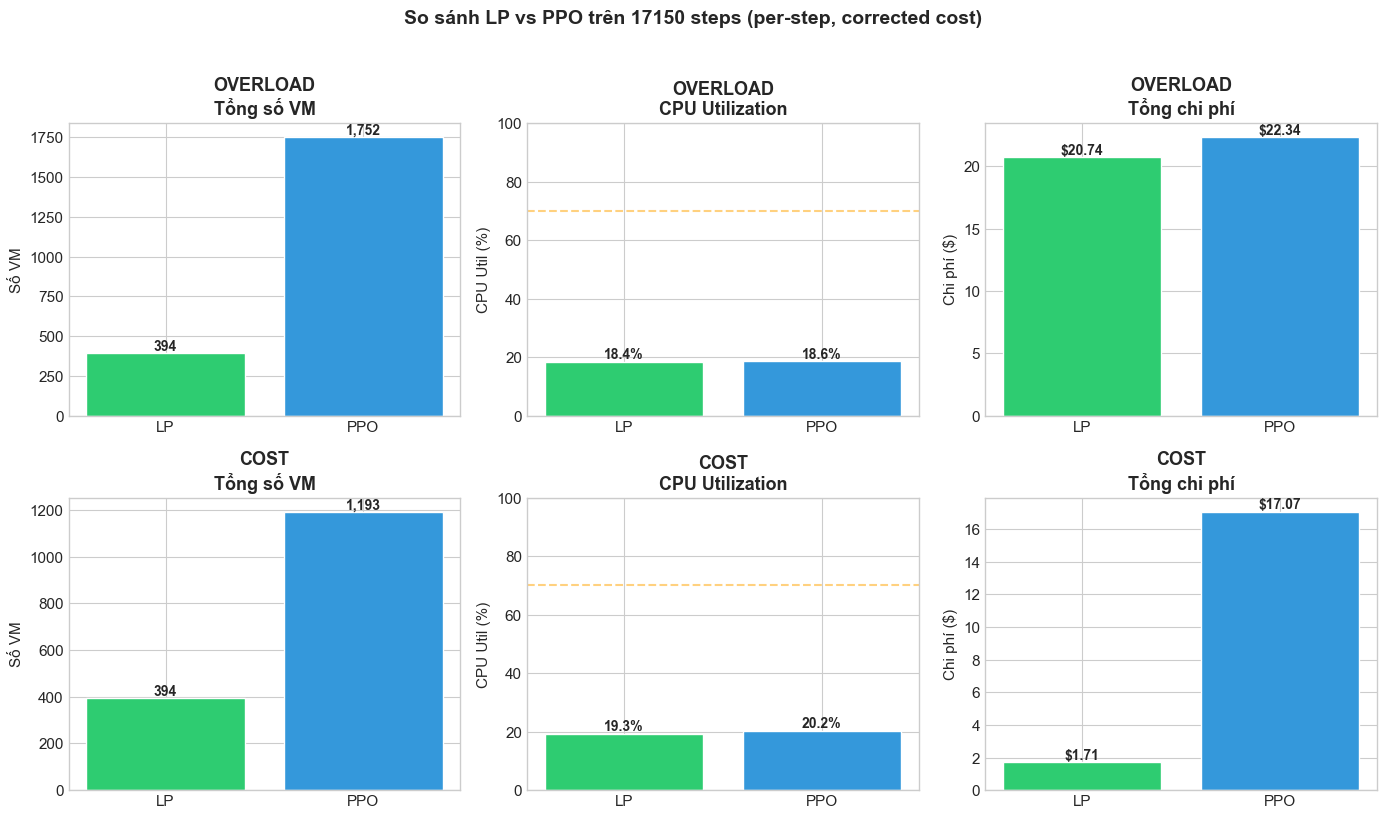

✓ Chart saved to forecast_result\lp_vs_ppo_by_scenario_corrected.png


In [133]:
def plot_scenario(metrics_list, scenario_name, ax_row):
    """Plot 3 criteria for a scenario"""
    if len(metrics_list) < 2:
        return
    
    df = pd.DataFrame(metrics_list).set_index('Method')
    methods = df.index.tolist()
    colors = [COLORS.get(m, '#999999') for m in methods]
    
    # 1. Total VMs
    ax = ax_row[0]
    vals = df['Total VMs'].values
    bars = ax.bar(methods, vals, color=colors, edgecolor='white')
    ax.set_title(f'{scenario_name}\nTổng số VM', fontweight='bold')
    ax.set_ylabel('Số VM')
    for bar, val in zip(bars, vals):
        ax.annotate(f'{val:,}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 2. CPU Utilization
    ax = ax_row[1]
    vals = df['CPU Util %'].values
    bars = ax.bar(methods, vals, color=colors, edgecolor='white')
    ax.set_title(f'{scenario_name}\nCPU Utilization', fontweight='bold')
    ax.set_ylabel('CPU Util (%)')
    ax.set_ylim(0, 100)
    ax.axhline(y=70, color='orange', linestyle='--', alpha=0.5)
    for bar, val in zip(bars, vals):
        ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 3. Total Cost
    ax = ax_row[2]
    vals = df['Total Cost ($)'].values
    bars = ax.bar(methods, vals, color=colors, edgecolor='white')
    ax.set_title(f'{scenario_name}\nTổng chi phí', fontweight='bold')
    ax.set_ylabel('Chi phí ($)')
    for bar, val in zip(bars, vals):
        ax.annotate(f'${val:.2f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

# Tạo figure 2 hàng (Overload, Cost) x 3 cột (VM, Util, Cost)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle(f'So sánh LP vs PPO trên {n_steps} steps (per-step, corrected cost)', 
             fontsize=14, fontweight='bold', y=1.02)

# Row 1: OVERLOAD scenario
plot_scenario(metrics_overload, 'OVERLOAD', axes[0])

# Row 2: COST scenario  
plot_scenario(metrics_cost, 'COST', axes[1])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'lp_vs_ppo_by_scenario_corrected.png', dpi=150, 
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'✓ Chart saved to {RESULTS_DIR / "lp_vs_ppo_by_scenario_corrected.png"}')


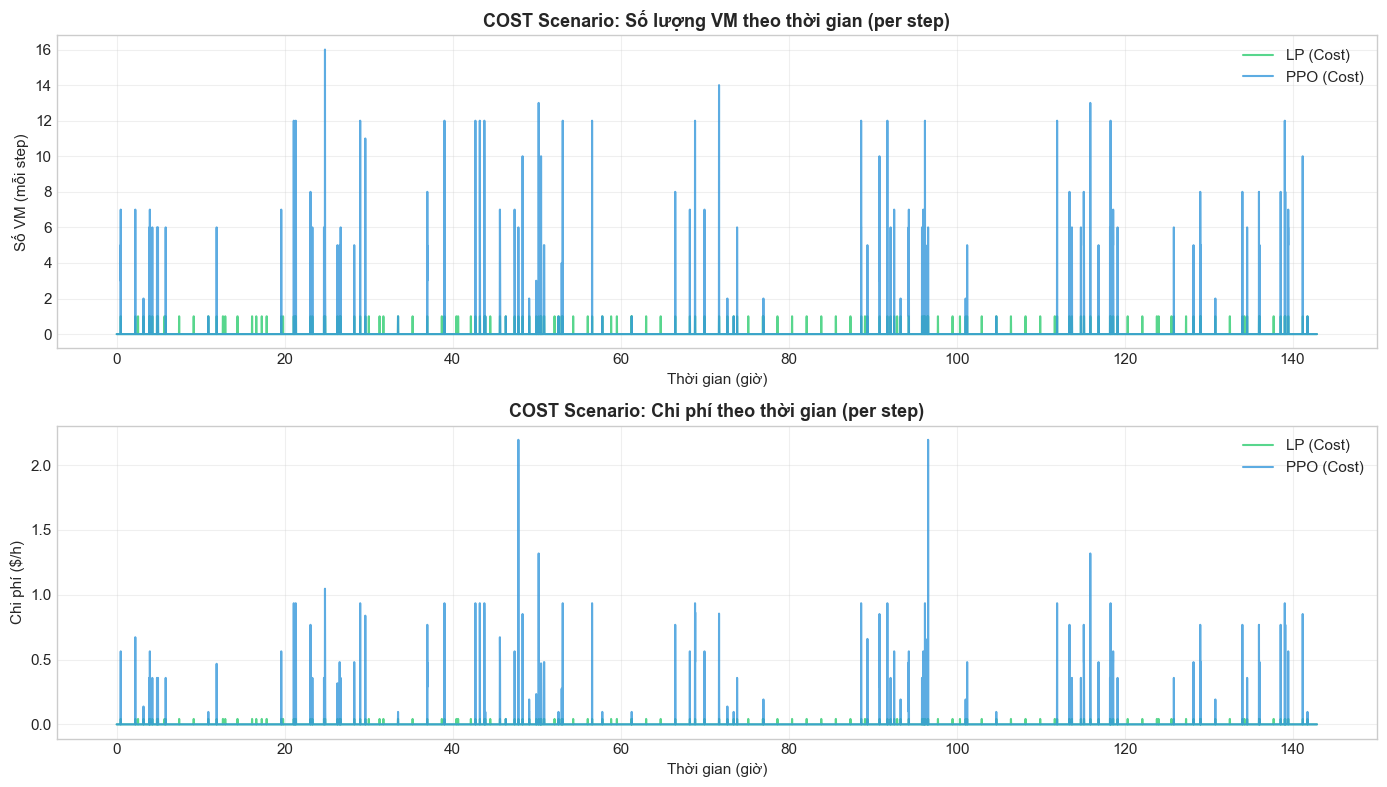

✓ Time series chart saved (raw values per step)


In [134]:
# Time series: VM count theo thời gian (Scenario: COST)
if lp_cost_df is not None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    x_hours = np.arange(n_steps) * 30 / 3600

    # Plot 1: VM Count (raw values per step)
    ax1 = axes[0]
    ax1.plot(x_hours, lp_cost_df['vm_count'], 
             label='LP (Cost)', color=COLORS['LP'], linewidth=1.5, alpha=0.8)
    ax1.plot(x_hours, ppo_cost_df['vm_count'], 
             label='PPO (Cost)', color=COLORS['PPO'], linewidth=1.5, alpha=0.8)
    ax1.set_xlabel('Thời gian (giờ)')
    ax1.set_ylabel('Số VM (mỗi step)')
    ax1.set_title('COST Scenario: Số lượng VM theo thời gian (per step)', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Cost (raw values per step)
    ax2 = axes[1]
    ax2.plot(x_hours, lp_cost_df['vm_cost_per_hour'], 
             label='LP (Cost)', color=COLORS['LP'], linewidth=1.5, alpha=0.8)
    ax2.plot(x_hours, ppo_cost_df['vm_cost_per_hour'], 
             label='PPO (Cost)', color=COLORS['PPO'], linewidth=1.5, alpha=0.8)
    ax2.set_xlabel('Thời gian (giờ)')
    ax2.set_ylabel('Chi phí ($/h)')
    ax2.set_title('COST Scenario: Chi phí theo thời gian (per step)', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'lp_vs_ppo_timeseries_cost_corrected.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print('✓ Time series chart saved (raw values per step)')


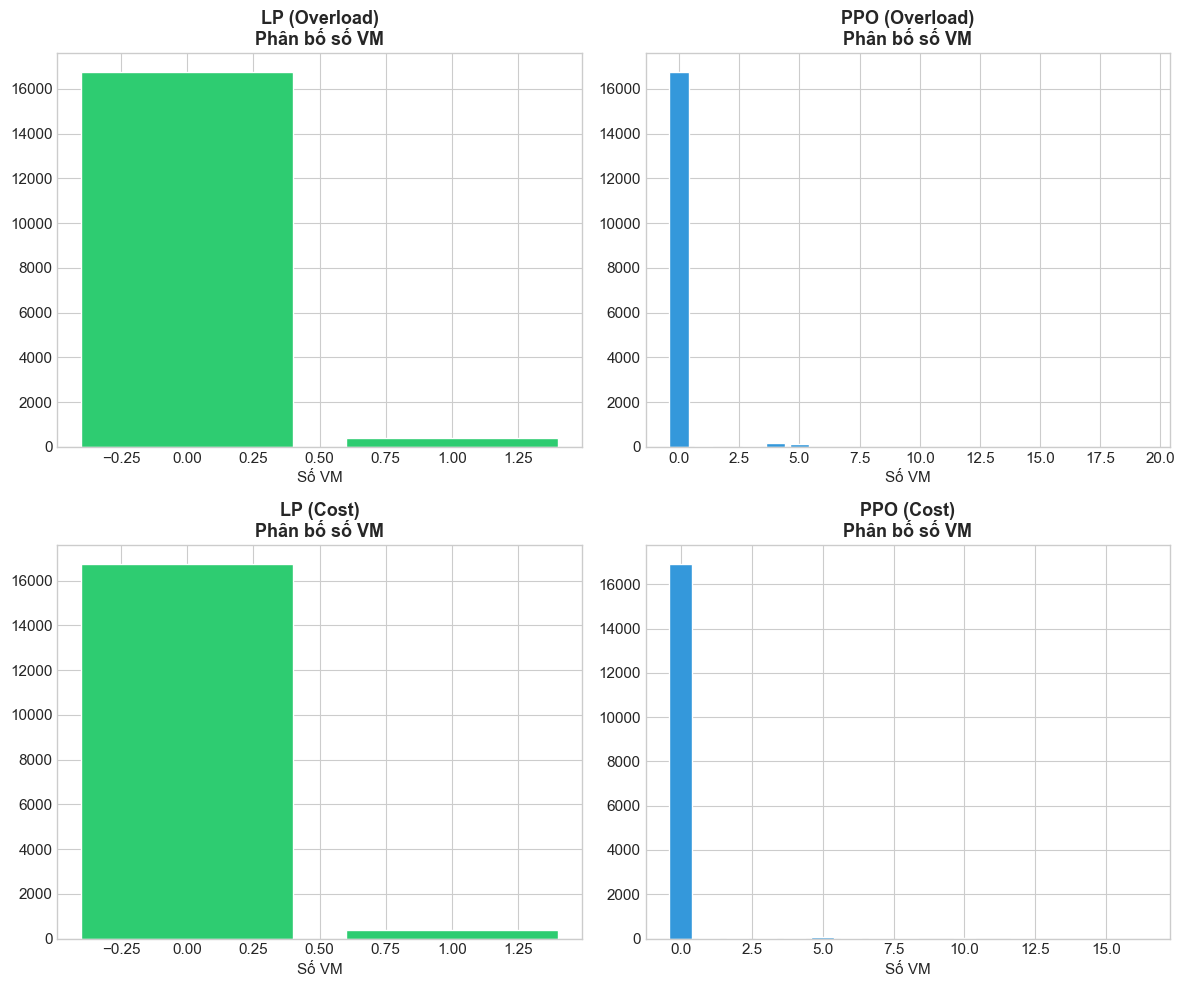

✓ VM distribution chart saved


In [135]:
# Distribution của số VM theo Scenario
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# OVERLOAD scenario
if lp_overload_df is not None:
    vm_counts = lp_overload_df['vm_count'].value_counts().sort_index()
    axes[0, 0].bar(vm_counts.index, vm_counts.values, color=COLORS['LP'], edgecolor='white')
    axes[0, 0].set_title('LP (Overload)\nPhân bố số VM', fontweight='bold')
    axes[0, 0].set_xlabel('Số VM')

vm_counts = ppo_overload_df['vm_count'].value_counts().sort_index()
axes[0, 1].bar(vm_counts.index, vm_counts.values, color=COLORS['PPO'], edgecolor='white')
axes[0, 1].set_title('PPO (Overload)\nPhân bố số VM', fontweight='bold')
axes[0, 1].set_xlabel('Số VM')

# COST scenario
if lp_cost_df is not None:
    vm_counts = lp_cost_df['vm_count'].value_counts().sort_index()
    axes[1, 0].bar(vm_counts.index, vm_counts.values, color=COLORS['LP'], edgecolor='white')
    axes[1, 0].set_title('LP (Cost)\nPhân bố số VM', fontweight='bold')
    axes[1, 0].set_xlabel('Số VM')

vm_counts = ppo_cost_df['vm_count'].value_counts().sort_index()
axes[1, 1].bar(vm_counts.index, vm_counts.values, color=COLORS['PPO'], edgecolor='white')
axes[1, 1].set_title('PPO (Cost)\nPhân bố số VM', fontweight='bold')
axes[1, 1].set_xlabel('Số VM')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'lp_vs_ppo_vm_distribution_corrected.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ VM distribution chart saved')


## 4.5. So sánh Host-Only vs With VM: Tầm quan trọng của VM Allocation

Visualize để nhấn mạnh việc thuê VM giải quyết SLA violations như thế nào khi chỉ dùng Host không đủ.


In [136]:
# Tính tình huống "chỉ dùng Host" (không có VM)
def calculate_host_only_scenario(df):
    """Tính utilization và violations nếu chỉ dùng Host (không có VM)"""
    host_cpu_threshold = HOST_SPEC["total_cpu_cores"] * HOST_SPEC["cpu_threshold_pct"] / 100.0
    host_mem_threshold = HOST_SPEC["total_memory_gb"] * HOST_SPEC["memory_threshold_pct"] / 100.0
    
    # Tính utilization và violations nếu chỉ dùng Host
    df_host_only = df.copy()
    
    if 'cpu_required_cores' in df.columns:
        # CPU utilization nếu chỉ dùng Host
        df_host_only['cpu_util_host_only'] = (df['cpu_required_cores'] / host_cpu_threshold * 100).clip(0, None)
        # SLA violation: cpu_required > host_cpu_threshold
        df_host_only['cpu_violation_host_only'] = (df['cpu_required_cores'] > host_cpu_threshold).astype(int)
    else:
        df_host_only['cpu_util_host_only'] = 0
        df_host_only['cpu_violation_host_only'] = 0
    
    if 'mem_required_gb' in df.columns:
        # Memory utilization nếu chỉ dùng Host
        df_host_only['mem_util_host_only'] = (df['mem_required_gb'] / host_mem_threshold * 100).clip(0, None)
        # SLA violation: mem_required > host_mem_threshold
        df_host_only['mem_violation_host_only'] = (df['mem_required_gb'] > host_mem_threshold).astype(int)
    else:
        df_host_only['mem_util_host_only'] = 0
        df_host_only['mem_violation_host_only'] = 0
    
    # Tổng SLA violation (CPU hoặc Memory)
    df_host_only['sla_violation_host_only'] = (
        (df_host_only['cpu_violation_host_only'] == 1) | 
        (df_host_only['mem_violation_host_only'] == 1)
    ).astype(int)
    
    return df_host_only

# Tính cho cả 2 scenarios
print("Tính toán tình huống Host-Only (không có VM)...")
if lp_overload_df is not None:
    lp_overload_host_only = calculate_host_only_scenario(lp_overload_df)
if ppo_overload_df is not None:
    ppo_overload_host_only = calculate_host_only_scenario(ppo_overload_df)
if lp_cost_df is not None:
    lp_cost_host_only = calculate_host_only_scenario(lp_cost_df)
if ppo_cost_df is not None:
    ppo_cost_host_only = calculate_host_only_scenario(ppo_cost_df)

print("✓ Host-only scenario calculated")


Tính toán tình huống Host-Only (không có VM)...
✓ Host-only scenario calculated


## 4.6. Giải thích CPU Utilization: Host-Only vs With VM (LP)

Visualization đơn giản để giải thích cách tính CPU Utilization và tầm quan trọng của VM Allocation.


  CPU UTILIZATION: Host-Only vs With VM (LP)

📊 Giải thích cách tính CPU Utilization:
  Host CPU Threshold = 1 cores × 70% = 0.70 cores
  
  1. Host-Only (không có VM):
     CPU Utilization = (CPU Required / 0.70 cores) × 100
     → Nếu > 100% → SLA Violation (vượt quá host capacity)
  
  2. With VM (LP thuê VM):
     CPU Utilization = (CPU Required / (Host Threshold + VM CPU)) × 100
     → Host Threshold = 0.70 cores
     → VM CPU = tổng CPU từ các VM được thuê
     → CPU Allocated Total = Host + VM CPU
     → Utilization giảm vì mẫu số tăng (có thêm VM CPU)


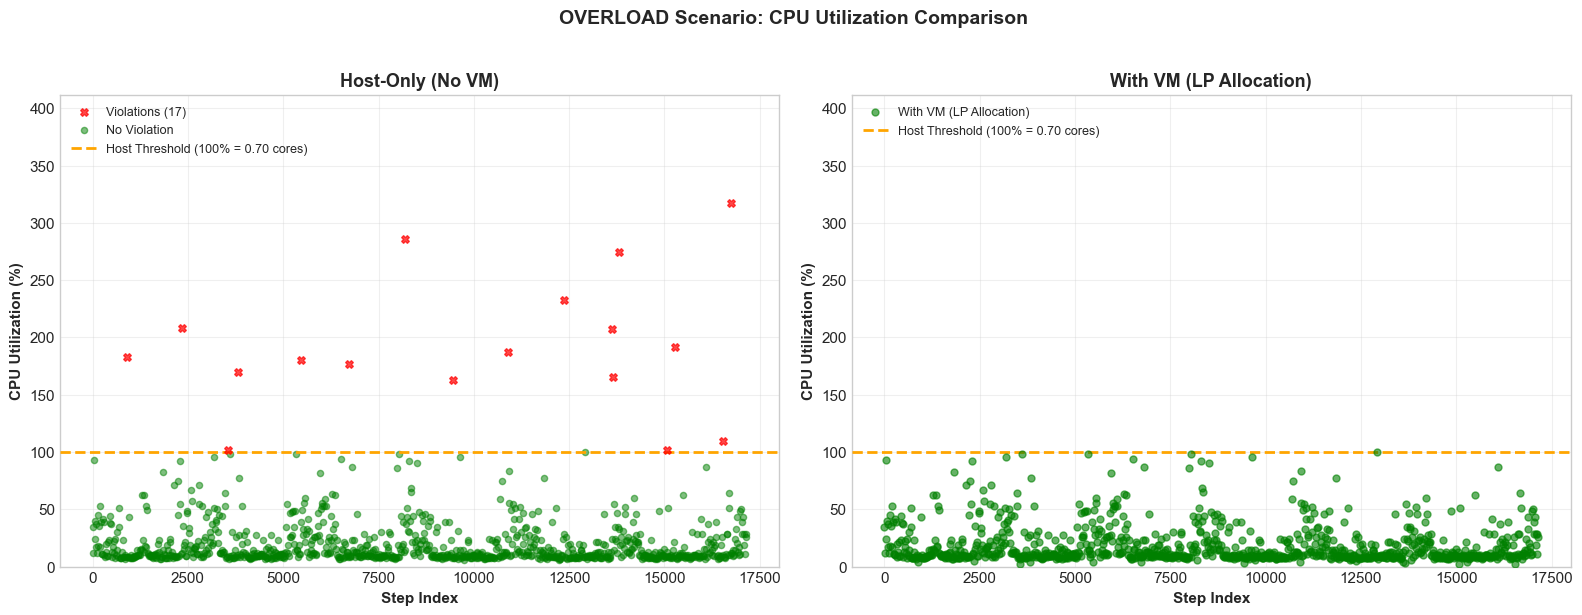

✓ CPU utilization comparison saved: cpu_util_comparison_host_vs_vm_overload_simple.png


In [138]:
# Visualization: CPU Utilization - Host-Only vs With VM (LP)
# Chỉ hiển thị 1 scenario (OVERLOAD) và chỉ CPU utilization

def plot_cpu_util_comparison_simple(df_actual, df_host_only, scenario_name='OVERLOAD'):
    """Visualize CPU Utilization: Host-Only vs With VM (LP)
    
    Giải thích:
    - Host-Only: CPU Util = (CPU Required / Host Threshold) × 100
    - With VM: CPU Util = (CPU Required / (Host Threshold + VM CPU)) × 100
    """
    if df_actual is None or df_host_only is None or len(df_actual) == 0:
        print(f"⚠️ Không có dữ liệu cho {scenario_name}")
        return
    
    host_cpu_threshold = HOST_SPEC["total_cpu_cores"] * HOST_SPEC["cpu_threshold_pct"] / 100.0
    
    # Tính CPU utilization cho từng step
    # Host-Only: cpu_required / host_threshold
    cpu_util_host_only = (df_host_only['cpu_required_cores'] / host_cpu_threshold * 100).values
    
    # With VM: cpu_required / cpu_allocated_total
    cpu_util_with_vm = (df_actual['cpu_required_cores'] / df_actual['cpu_allocated_cores'] * 100).values
    
    # Lấy một sample để visualization (ví dụ: 1000 steps đầu hoặc random sample)
    n_steps = len(df_actual)
    sample_size = min(1000, n_steps)
    step_indices = np.linspace(0, n_steps-1, sample_size, dtype=int)
    
    # Tạo 2 subplots cạnh nhau
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Phân loại violations
    violation_mask = df_host_only['sla_violation_host_only'].values[step_indices] == 1
    no_violation_mask = ~violation_mask
    
    # ===== SUBPLOT 1: Host-Only =====
    ax1 = axes[0]
    
    # Scatter Host-Only violations (màu đỏ)
    if violation_mask.sum() > 0:
        violation_steps = step_indices[violation_mask]
        ax1.scatter(violation_steps, cpu_util_host_only[violation_steps], 
                   alpha=0.7, s=30, label=f'Violations ({violation_mask.sum()})', 
                   color='red', marker='X', zorder=10)
    
    # Scatter Host-Only no violations (cùng màu xanh như With VM)
    if no_violation_mask.sum() > 0:
        no_violation_steps = step_indices[no_violation_mask]
        ax1.scatter(no_violation_steps, cpu_util_host_only[no_violation_steps], 
                   alpha=0.5, s=20, label='No Violation', 
                   color='green', marker='o', zorder=5)
    
    # Đường threshold 100%
    ax1.axhline(y=100, color='orange', linestyle='--', linewidth=2, 
               label=f'Host Threshold (100% = {host_cpu_threshold:.2f} cores)', zorder=5)
    
    ax1.set_xlabel('Step Index', fontweight='bold', fontsize=11)
    ax1.set_ylabel('CPU Utilization (%)', fontweight='bold', fontsize=11)
    ax1.set_title('Host-Only (No VM)', fontweight='bold', fontsize=13)
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(alpha=0.3)
    ax1.set_ylim(0, max(150, cpu_util_host_only.max() * 1.1))
    
    # ===== SUBPLOT 2: With VM (LP) =====
    ax2 = axes[1]
    
    # Scatter With VM (màu xanh)
    ax2.scatter(step_indices, cpu_util_with_vm[step_indices], 
               alpha=0.6, s=25, label='With VM (LP Allocation)', 
               color='green', marker='o', zorder=8)
    
    # Đường threshold 100%
    ax2.axhline(y=100, color='orange', linestyle='--', linewidth=2, 
               label=f'Host Threshold (100% = {host_cpu_threshold:.2f} cores)', zorder=5)
    
    ax2.set_xlabel('Step Index', fontweight='bold', fontsize=11)
    ax2.set_ylabel('CPU Utilization (%)', fontweight='bold', fontsize=11)
    ax2.set_title('With VM (LP Allocation)', fontweight='bold', fontsize=13)
    ax2.legend(loc='upper left', fontsize=9)
    ax2.grid(alpha=0.3)
    ax2.set_ylim(0, max(150, cpu_util_host_only.max() * 1.1))
    
    # Title chung cho cả figure
    fig.suptitle(f'{scenario_name} Scenario: CPU Utilization Comparison', 
                fontweight='bold', fontsize=14, y=1.02)
    
    plt.tight_layout()
    filename = RESULTS_DIR / f'cpu_util_comparison_host_vs_vm_{scenario_name.lower()}_simple.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'✓ CPU utilization comparison saved: {filename.name}')

# Chỉ visualize OVERLOAD scenario với LP
print("="*70)
print("  CPU UTILIZATION: Host-Only vs With VM (LP)")
print("="*70)

host_cpu_threshold = HOST_SPEC["total_cpu_cores"] * HOST_SPEC["cpu_threshold_pct"] / 100.0
print(f"\n📊 Giải thích cách tính CPU Utilization:")
print(f"  Host CPU Threshold = {HOST_SPEC['total_cpu_cores']} cores × {HOST_SPEC['cpu_threshold_pct']}% = {host_cpu_threshold:.2f} cores")
print(f"  ")
print(f"  1. Host-Only (không có VM):")
print(f"     CPU Utilization = (CPU Required / {host_cpu_threshold:.2f} cores) × 100")
print(f"     → Nếu > 100% → SLA Violation (vượt quá host capacity)")
print(f"  ")
print(f"  2. With VM (LP thuê VM):")
print(f"     CPU Utilization = (CPU Required / (Host Threshold + VM CPU)) × 100")
print(f"     → Host Threshold = {host_cpu_threshold:.2f} cores")
print(f"     → VM CPU = tổng CPU từ các VM được thuê")
print(f"     → CPU Allocated Total = Host + VM CPU")
print(f"     → Utilization giảm vì mẫu số tăng (có thêm VM CPU)")

if lp_overload_df is not None and 'lp_overload_host_only' in locals():
    plot_cpu_util_comparison_simple(lp_overload_df, lp_overload_host_only, 'OVERLOAD')
else:
    print("\n⚠️ Chưa có dữ liệu lp_overload_host_only. Chạy Cell 18 trước.")


In [139]:
# Bảng thống kê: Host-Only vs With VM - Tầm quan trọng của VM Allocation
print("="*70)
print("  THỐNG KÊ: HOST-ONLY vs WITH VM - TẦM QUAN TRỌNG CỦA VM ALLOCATION")
print("="*70)

host_cpu_threshold = HOST_SPEC["total_cpu_cores"] * HOST_SPEC["cpu_threshold_pct"] / 100.0
host_mem_threshold = HOST_SPEC["total_memory_gb"] * HOST_SPEC["memory_threshold_pct"] / 100.0

print(f"\nHost Specifications:")
print(f"  CPU Threshold: {host_cpu_threshold:.2f} cores ({HOST_SPEC['cpu_threshold_pct']}% of {HOST_SPEC['total_cpu_cores']} cores)")
print(f"  Memory Threshold: {host_mem_threshold:.2f} GB ({HOST_SPEC['memory_threshold_pct']}% of {HOST_SPEC['total_memory_gb']} GB)")

scenarios_data = [
    ('OVERLOAD', lp_overload_df, ppo_overload_df, 'lp_overload_host_only', 'ppo_overload_host_only'),
    ('COST', lp_cost_df, ppo_cost_df, 'lp_cost_host_only', 'ppo_cost_host_only'),
]

for scenario_name, lp_df, ppo_df, lp_host_var, ppo_host_var in scenarios_data:
    if lp_df is None and ppo_df is None:
        continue
    
    print(f"\n{'='*70}")
    print(f"  SCENARIO: {scenario_name}")
    print(f"{'='*70}")
    
    for name, df_actual, df_host_only_var in [('LP', lp_df, lp_host_var), ('PPO', ppo_df, ppo_host_var)]:
        if df_actual is None or df_host_only_var not in locals():
            continue
        
        df_host_only = locals()[df_host_only_var]
        
        # Thống kê violations
        violations_host_only = int(df_host_only['sla_violation_host_only'].sum())
        violations_actual = int(df_actual['sla_violation_flag'].sum()) if 'sla_violation_flag' in df_actual.columns else 0
        violations_solved = violations_host_only - violations_actual
        
        # CPU violations
        cpu_violations_host_only = int(df_host_only['cpu_violation_host_only'].sum())
        mem_violations_host_only = int(df_host_only['mem_violation_host_only'].sum())
        
        print(f"\n{name}:")
        print(f"  📊 SLA Violations:")
        print(f"    - Nếu chỉ dùng Host:  {violations_host_only:>5} violations ({violations_host_only/len(df_host_only)*100:.2f}%)")
        print(f"      • CPU violations:    {cpu_violations_host_only:>5}")
        print(f"      • Memory violations: {mem_violations_host_only:>5}")
        print(f"    - Với VM Allocation:  {violations_actual:>5} violations ({violations_actual/len(df_actual)*100:.2f}%)")
        print(f"    - ✅ Đã giải quyết:    {violations_solved:>5} violations ({violations_solved/violations_host_only*100:.1f}% of host-only violations)" if violations_host_only > 0 else "    - ✅ Không có violations để giải quyết")
        
        # Utilization tại violation steps
        violation_steps = df_host_only[df_host_only['sla_violation_host_only'] == 1]
        if len(violation_steps) > 0:
            avg_cpu_util_viol = violation_steps['cpu_util_host_only'].mean()
            avg_mem_util_viol = violation_steps['mem_util_host_only'].mean()
            max_cpu_util_viol = violation_steps['cpu_util_host_only'].max()
            max_mem_util_viol = violation_steps['mem_util_host_only'].max()
            
            print(f"\n  📈 Utilization tại Violation Steps (Host-Only):")
            print(f"    - CPU:  Avg {avg_cpu_util_viol:.1f}%, Max {max_cpu_util_viol:.1f}%")
            print(f"    - Memory: Avg {avg_mem_util_viol:.1f}%, Max {max_mem_util_viol:.1f}%")
            print(f"    → Vượt quá Host threshold (>100%) → Cần VM để giải quyết!")


  THỐNG KÊ: HOST-ONLY vs WITH VM - TẦM QUAN TRỌNG CỦA VM ALLOCATION

Host Specifications:
  CPU Threshold: 0.70 cores (70% of 1 cores)
  Memory Threshold: 3.00 GB (75% of 4 GB)

  SCENARIO: OVERLOAD

LP:
  📊 SLA Violations:
    - Nếu chỉ dùng Host:    394 violations (2.30%)
      • CPU violations:      394
      • Memory violations:     0
    - Với VM Allocation:      0 violations (0.00%)
    - ✅ Đã giải quyết:      394 violations (100.0% of host-only violations)

  📈 Utilization tại Violation Steps (Host-Only):
    - CPU:  Avg 169.2%, Max 374.3%
    - Memory: Avg 8.5%, Max 17.5%
    → Vượt quá Host threshold (>100%) → Cần VM để giải quyết!

PPO:
  📊 SLA Violations:
    - Nếu chỉ dùng Host:    394 violations (2.30%)
      • CPU violations:      394
      • Memory violations:     0
    - Với VM Allocation:      5 violations (0.03%)
    - ✅ Đã giải quyết:      389 violations (98.7% of host-only violations)

  📈 Utilization tại Violation Steps (Host-Only):
    - CPU:  Avg 169.2%, Max 374.

## 5. Phân tích Chi tiết


In [140]:
# Phân tích chi tiết theo SCENARIO
def analyze_scenario(metrics_list, scenario_name):
    """Phân tích và so sánh LP vs PPO cho một scenario"""
    if len(metrics_list) < 2:
        print(f"⚠️ Thiếu dữ liệu cho scenario {scenario_name}")
        return None
    
    lp_m = metrics_list[0]  # LP
    ppo_m = metrics_list[1]  # PPO
    
    print(f"\n{'='*60}")
    print(f"    SCENARIO: {scenario_name}")
    print(f"{'='*60}")
    
    # VM comparison
    print("\n📊 Tổng số VM:")
    print(f"   LP:  {lp_m['Total VMs']:>6} VMs (avg {lp_m['Avg VMs/Step']:.2f}/step)")
    print(f"   PPO: {ppo_m['Total VMs']:>6} VMs (avg {ppo_m['Avg VMs/Step']:.2f}/step)")
    if lp_m['Total VMs'] > 0:
        diff = (ppo_m['Total VMs'] - lp_m['Total VMs']) / lp_m['Total VMs'] * 100
        print(f"   → PPO {'nhiều hơn' if diff > 0 else 'ít hơn'} LP: {abs(diff):.1f}%")
    
    # Utilization (total system: host + VM)
    print("\n📊 CPU Utilization (total system: host + VM):")
    print(f"   LP:  {lp_m['CPU Util %']:>6.1f}% (Overall)")
    if 'CPU Util % (Host Only)' in lp_m:
        print(f"        Host Only: {lp_m['CPU Util % (Host Only)']:>6.1f}%")
        print(f"        With VM:   {lp_m['CPU Util % (With VM)']:>6.1f}%")
    print(f"   PPO: {ppo_m['CPU Util %']:>6.1f}% (Overall)")
    if 'CPU Util % (Host Only)' in ppo_m:
        print(f"        Host Only: {ppo_m['CPU Util % (Host Only)']:>6.1f}%")
        print(f"        With VM:   {ppo_m['CPU Util % (With VM)']:>6.1f}%")
    
    print("\n📊 Memory Utilization (total system: host + VM):")
    print(f"   LP:  {lp_m['Mem Util %']:>6.1f}% (Overall)")
    if 'Mem Util % (Host Only)' in lp_m:
        print(f"        Host Only: {lp_m['Mem Util % (Host Only)']:>6.1f}%")
        print(f"        With VM:   {lp_m['Mem Util % (With VM)']:>6.1f}%")
    print(f"   PPO: {ppo_m['Mem Util %']:>6.1f}% (Overall)")
    if 'Mem Util % (Host Only)' in ppo_m:
        print(f"        Host Only: {ppo_m['Mem Util % (Host Only)']:>6.1f}%")
        print(f"        With VM:   {ppo_m['Mem Util % (With VM)']:>6.1f}%")
    
    # Cost breakdown
    print("\n📊 Chi phí vận hành (corrected):")
    print(f"   LP Total Cost:  ${lp_m['Total Cost ($)']:>8.4f}")
    if 'Total VM Cost ($)' in lp_m:
        print(f"     - VM Cost:      ${lp_m['Total VM Cost ($)']:>8.4f} (time-based)")
        print(f"     - Switching:     ${lp_m['Total Switching Cost ($)']:>8.4f} (one-time)")
    print(f"   PPO Total Cost: ${ppo_m['Total Cost ($)']:>8.4f}")
    if 'Total VM Cost ($)' in ppo_m:
        print(f"     - VM Cost:      ${ppo_m['Total VM Cost ($)']:>8.4f} (time-based)")
        print(f"     - Switching:     ${ppo_m['Total Switching Cost ($)']:>8.4f} (one-time)")
    if lp_m['Total Cost ($)'] > 0:
        diff = (ppo_m['Total Cost ($)'] - lp_m['Total Cost ($)']) / lp_m['Total Cost ($)'] * 100
        print(f"   → PPO {'đắt hơn' if diff > 0 else 'rẻ hơn'} LP: {abs(diff):.1f}%")
    
    # SLA
    print("\n📊 Vi phạm SLA:")
    print(f"   LP:  {lp_m['SLA Violations']:>4} ({lp_m['SLA Violations']/lp_m['Steps']*100:.2f}%)")
    print(f"   PPO: {ppo_m['SLA Violations']:>4} ({ppo_m['SLA Violations']/ppo_m['Steps']*100:.2f}%)")
    
    # Winner for each criterion
    return {
        'scenario': scenario_name,
        'vm': 'LP' if lp_m['Total VMs'] <= ppo_m['Total VMs'] else 'PPO',
        'util': 'LP' if lp_m['CPU Util %'] >= ppo_m['CPU Util %'] else 'PPO',
        'cost': 'LP' if lp_m['Total Cost ($)'] <= ppo_m['Total Cost ($)'] else 'PPO',
        'sla': 'LP' if lp_m['SLA Violations'] <= ppo_m['SLA Violations'] else 'PPO',
    }

print("="*70)
print("  PHÂN TÍCH CHI TIẾT LP vs PPO (CORRECTED: Cost & Utilization)")
print("="*70)

results_overload = analyze_scenario(metrics_overload, 'OVERLOAD') if len(metrics_overload) >= 2 else None
results_cost = analyze_scenario(metrics_cost, 'COST') if len(metrics_cost) >= 2 else None


  PHÂN TÍCH CHI TIẾT LP vs PPO (CORRECTED: Cost & Utilization)

    SCENARIO: OVERLOAD

📊 Tổng số VM:
   LP:     394 VMs (avg 0.02/step)
   PPO:   1752 VMs (avg 0.10/step)
   → PPO nhiều hơn LP: 344.7%

📊 CPU Utilization (total system: host + VM):
   LP:    18.4% (Overall)
        Host Only:   18.7%
        With VM:      3.6%
   PPO:   18.6% (Overall)
        Host Only:   18.8%
        With VM:     11.6%

📊 Memory Utilization (total system: host + VM):
   LP:     7.8% (Overall)
        Host Only:    7.9%
        With VM:      0.2%
   PPO:    7.8% (Overall)
        Host Only:    7.9%
        With VM:      0.7%

📊 Chi phí vận hành (corrected):
   LP Total Cost:  $ 20.7432
     - VM Cost:      $  5.0432 (time-based)
     - Switching:     $ 15.7000 (one-time)
   PPO Total Cost: $ 22.3444
     - VM Cost:      $  1.5444 (time-based)
     - Switching:     $ 20.8000 (one-time)
   → PPO đắt hơn LP: 7.7%

📊 Vi phạm SLA:
   LP:     0 (0.00%)
   PPO:    5 (0.03%)

    SCENARIO: COST

📊 Tổng số VM:

In [141]:
# Tổng kết winner
print("\n" + "="*70)
print("                         TỔNG KẾT WINNER")
print("="*70)
print(f"\n{'Tiêu chí':<25} {'OVERLOAD':>15} {'COST':>15}")
print("-"*55)
if results_overload and results_cost:
    print(f"{'Ít VM hơn':<25} {results_overload['vm']:>15} {results_cost['vm']:>15}")
    print(f"{'Hiệu quả hơn (CPU)':<25} {results_overload['util']:>15} {results_cost['util']:>15}")
    print(f"{'Chi phí thấp hơn':<25} {results_overload['cost']:>15} {results_cost['cost']:>15}")
    print(f"{'SLA tốt hơn':<25} {results_overload['sla']:>15} {results_cost['sla']:>15}")



                         TỔNG KẾT WINNER

Tiêu chí                         OVERLOAD            COST
-------------------------------------------------------
Ít VM hơn                              LP              LP
Hiệu quả hơn (CPU)                    PPO             PPO
Chi phí thấp hơn                       LP              LP
SLA tốt hơn                            LP              LP


In [142]:
# Nhận xét
print("\n" + "-"*70)
print("NHẬN XÉT:")
print("-"*70)
print("""
• LP (Linear Programming):
  - Giải tối ưu chính xác tại mỗi thời điểm
  - Reactive: chỉ dùng thông tin hiện tại
  - Hai kịch bản: Overload (capacity-first) và Cost (cost-first)

• PPO (Proximal Policy Optimization):
  - Học từ dữ liệu, có thể học pattern
  - Hai kịch bản với reward weights khác nhau
  - Post-processing: Host-only khi không có overflow

• Cost Calculation (CORRECTED):
  - Steps liên tiếp (30 giây/step)
  - VM Cost: per-hour cost, nhân với (30/3600) cho mỗi step
  - Switching Cost: one-time cost mỗi lần switch (KHÔNG nhân với thời gian)
  - Total Cost = VM Cost (time-based) + Switching Cost (one-time)

• CPU/Memory Utilization (CORRECTED):
  - Tính trên tổng hệ thống (Host + VM)
  - CPU Util = (CPU required) / (CPU allocated total) × 100
  - Memory Util = (Memory required) / (Memory allocated total) × 100
  - Phản ánh utilization thực tế của cả hệ thống
""")



----------------------------------------------------------------------
NHẬN XÉT:
----------------------------------------------------------------------

• LP (Linear Programming):
  - Giải tối ưu chính xác tại mỗi thời điểm
  - Reactive: chỉ dùng thông tin hiện tại
  - Hai kịch bản: Overload (capacity-first) và Cost (cost-first)

• PPO (Proximal Policy Optimization):
  - Học từ dữ liệu, có thể học pattern
  - Hai kịch bản với reward weights khác nhau
  - Post-processing: Host-only khi không có overflow

• Cost Calculation (CORRECTED):
  - Steps liên tiếp (30 giây/step)
  - VM Cost: per-hour cost, nhân với (30/3600) cho mỗi step
  - Switching Cost: one-time cost mỗi lần switch (KHÔNG nhân với thời gian)
  - Total Cost = VM Cost (time-based) + Switching Cost (one-time)

• CPU/Memory Utilization (CORRECTED):
  - Tính trên tổng hệ thống (Host + VM)
  - CPU Util = (CPU required) / (CPU allocated total) × 100
  - Memory Util = (Memory required) / (Memory allocated total) × 100
  - Phản ánh 

In [143]:
# Summary table with all 4 methods
print("\n" + "="*70)
print("           BẢNG TỔNG HỢP TẤT CẢ PHƯƠNG PHÁP")
print("="*70)

all_methods = []
if len(metrics_overload) >= 2:
    all_methods.append({**metrics_overload[0], 'Method': 'LP (Overload)'})
    all_methods.append({**metrics_overload[1], 'Method': 'PPO (Overload)'})
if len(metrics_cost) >= 2:
    all_methods.append({**metrics_cost[0], 'Method': 'LP (Cost)'})
    all_methods.append({**metrics_cost[1], 'Method': 'PPO (Cost)'})

if all_methods:
    summary_df = pd.DataFrame(all_methods).set_index('Method')
    # Hiển thị các metrics chính
    display_cols = ['Total VMs', 'CPU Util %', 'Mem Util %', 'Total Cost ($)', 'SLA Violations']
    if 'Total VM Cost ($)' in summary_df.columns:
        display_cols.insert(-1, 'Total VM Cost ($)')
    if 'Total Switching Cost ($)' in summary_df.columns:
        display_cols.insert(-1, 'Total Switching Cost ($)')
    display(summary_df[display_cols])



           BẢNG TỔNG HỢP TẤT CẢ PHƯƠNG PHÁP


,Total VMs,CPU Util %,Mem Util %,Total Cost ($),Total VM Cost ($),Total Switching Cost ($),SLA Violations
Method,,,,,,,
LP (Overload),394,18.36,7.75,20.7432,5.0432,15.70,0
PPO (Overload),1752,18.59,7.76,22.3444,1.5444,20.80,5
LP (Cost),394,19.29,7.83,1.7066,0.1366,1.57,0
PPO (Cost),1193,20.23,7.83,17.0739,0.8439,16.23,174


## 6. Kết luận & Nhận xét


In [144]:
# Kết luận cuối cùng
print('='*70)
print('                         KẾT LUẬN')
print('='*70)

if all_methods:
    # Xác định tốt nhất overall
    best_vm = min(all_methods, key=lambda x: x['Total VMs'])
    best_util = max(all_methods, key=lambda x: x['CPU Util %'])
    best_cost = min(all_methods, key=lambda x: x['Total Cost ($)'])
    best_sla = min(all_methods, key=lambda x: x['SLA Violations'])
    
    print(f"\n🏆 Ít VM nhất (overall):          {best_vm['Method']}")
    print(f"🏆 CPU hiệu quả nhất (overall):   {best_util['Method']}")
    print(f"🏆 Chi phí thấp nhất (overall):   {best_cost['Method']}")
    print(f"🏆 SLA tốt nhất (overall):        {best_sla['Method']}")


                         KẾT LUẬN

🏆 Ít VM nhất (overall):          LP (Overload)
🏆 CPU hiệu quả nhất (overall):   PPO (Cost)
🏆 Chi phí thấp nhất (overall):   LP (Cost)
🏆 SLA tốt nhất (overall):        LP (Overload)


## 7. Xuất CSV So sánh Chi tiết (Per-Step)


In [145]:
# Tạo CSV so sánh chi tiết cho từng scenario
def create_comparison_csv(lp_df, ppo_df, test_targets_df, scenario_name):
    """Tạo DataFrame so sánh chi tiết giữa LP và PPO cho một scenario"""
    
    # Tạo comparison DataFrame
    comparison_df = pd.DataFrame()
    
    # Timestamp
    comparison_df['timestamp'] = lp_df['timestamp']
    
    # Merge với test targets để lấy target fields và mem_required_gb
    if test_targets_df is not None:
        # Chuẩn hóa timestamp để merge
        test_targets_work = test_targets_df.copy()
        
        # Nếu test_targets có 'datetime', tạo 'timestamp' từ đó để merge
        if 'datetime' in test_targets_work.columns and 'timestamp' not in test_targets_work.columns:
            test_targets_work['timestamp'] = pd.to_datetime(test_targets_work['datetime'])
        elif 'datetime' in test_targets_work.columns:
            # Cả hai đều có, dùng datetime để merge
            test_targets_work['timestamp'] = pd.to_datetime(test_targets_work['datetime'])
        
        # Đảm bảo timestamp trong test_targets là datetime
        if 'timestamp' in test_targets_work.columns:
            test_targets_work['timestamp'] = pd.to_datetime(test_targets_work['timestamp'])
        
        # Merge với LP để lấy target fields
        lp_merged = lp_df.merge(
            test_targets_work[['timestamp', 'memory_usage_pct', 'cpu_total_usage', 'system_load', 'mem_required_gb']],
            on='timestamp',
            how='left',
            suffixes=('', '_target')
        )
        
        # Lấy target fields từ merged data
        comparison_df['memory_usage_pct'] = lp_merged['memory_usage_pct_target'] if 'memory_usage_pct_target' in lp_merged.columns else lp_merged.get('memory_usage_pct', np.nan)
        comparison_df['cpu_total_usage'] = lp_merged['cpu_total_usage_target'] if 'cpu_total_usage_target' in lp_merged.columns else lp_merged.get('cpu_total_usage', np.nan)
        comparison_df['system_load'] = lp_merged['system_load_target'] if 'system_load_target' in lp_merged.columns else lp_merged.get('system_load', np.nan)
        comparison_df['mem_required_gb'] = lp_merged['mem_required_gb_target'] if 'mem_required_gb_target' in lp_merged.columns else lp_merged.get('mem_required_gb', np.nan)
    else:
        # Fallback: lấy từ LP nếu có
        comparison_df['memory_usage_pct'] = lp_df.get('memory_usage_pct', np.nan)
        comparison_df['cpu_total_usage'] = lp_df.get('cpu_total_usage', np.nan)
        comparison_df['system_load'] = lp_df.get('system_load', np.nan)
        comparison_df['mem_required_gb'] = lp_df.get('mem_required_gb', np.nan)
    
    # Overflow values từ LP (required và overflow)
    comparison_df['cpu_required_cores'] = lp_df.get('cpu_required_cores', np.nan)
    comparison_df['mem_required_gb_from_lp'] = lp_df.get('mem_required_gb', comparison_df.get('mem_required_gb', np.nan))
    comparison_df['cpu_overflow_cores'] = lp_df.get('cpu_overflow_cores', np.nan)
    comparison_df['mem_overflow_gb'] = lp_df.get('mem_overflow_gb', np.nan)
    
    # LP Allocation và Metrics
    comparison_df['lp_allocation'] = lp_df['allocation']
    comparison_df['lp_vm_count'] = lp_df['vm_count']
    comparison_df['lp_vm_cost_per_hour'] = lp_df.get('vm_cost_per_hour', np.nan)
    comparison_df['lp_switching_cost'] = lp_df.get('switching_cost', np.nan)
    comparison_df['lp_total_cost_per_hour'] = lp_df.get('total_cost_per_hour', np.nan)
    comparison_df['lp_cpu_allocated_cores'] = lp_df.get('cpu_allocated_cores', np.nan)
    comparison_df['lp_mem_allocated_gb'] = lp_df.get('mem_allocated_gb', np.nan)
    comparison_df['lp_cpu_vm_only'] = lp_df.get('cpu_vm_only', np.nan)
    comparison_df['lp_mem_vm_only'] = lp_df.get('mem_vm_only', np.nan)
    comparison_df['lp_cpu_utilization_pct'] = lp_df.get('cpu_utilization_pct', np.nan)
    comparison_df['lp_mem_utilization_pct'] = lp_df.get('mem_utilization_pct', np.nan)
    comparison_df['lp_sla_violation_flag'] = lp_df.get('sla_violation_flag', lp_df.get('sla_violation', 0))
    
    # PPO Allocation và Metrics
    comparison_df['ppo_allocation'] = ppo_df['allocation']
    comparison_df['ppo_vm_count'] = ppo_df['vm_count']
    comparison_df['ppo_vm_cost_per_hour'] = ppo_df.get('vm_cost_per_hour', np.nan)
    comparison_df['ppo_switching_cost'] = ppo_df.get('switching_cost', np.nan)
    comparison_df['ppo_total_cost_per_hour'] = ppo_df.get('total_cost_per_hour', np.nan)
    comparison_df['ppo_cpu_allocated_cores'] = ppo_df.get('cpu_allocated_cores', np.nan)
    comparison_df['ppo_mem_allocated_gb'] = ppo_df.get('mem_allocated_gb', np.nan)
    comparison_df['ppo_cpu_vm_only'] = ppo_df.get('cpu_vm_only', np.nan)
    comparison_df['ppo_mem_vm_only'] = ppo_df.get('mem_vm_only', np.nan)
    comparison_df['ppo_cpu_utilization_pct'] = ppo_df.get('cpu_utilization_pct', np.nan)
    comparison_df['ppo_mem_utilization_pct'] = ppo_df.get('mem_utilization_pct', np.nan)
    comparison_df['ppo_sla_violation_flag'] = ppo_df.get('sla_violation_flag', 0)
    
    # Differences (PPO - LP)
    comparison_df['vm_count_diff'] = comparison_df['ppo_vm_count'] - comparison_df['lp_vm_count']
    comparison_df['cost_diff'] = comparison_df['ppo_total_cost_per_hour'] - comparison_df['lp_total_cost_per_hour']
    comparison_df['cpu_util_diff'] = comparison_df['ppo_cpu_utilization_pct'] - comparison_df['lp_cpu_utilization_pct']
    comparison_df['mem_util_diff'] = comparison_df['ppo_mem_utilization_pct'] - comparison_df['lp_mem_utilization_pct']
    comparison_df['sla_violation_diff'] = comparison_df['ppo_sla_violation_flag'] - comparison_df['lp_sla_violation_flag']
    
    return comparison_df

print("="*80)
print("CREATING COMPARISON CSV FILES (CORRECTED)")
print("="*80)

# Tạo comparison cho OVERLOAD scenario
if lp_overload_df is not None:
    comparison_overload = create_comparison_csv(
        lp_overload_df, ppo_overload_df, test_targets_df, 'OVERLOAD'
    )
    comparison_overload_path = RESULTS_DIR / 'lp_vs_ppo_comparison_corrected_overload.csv'
    comparison_overload.to_csv(comparison_overload_path, index=False)
    print(f'\n✓ Saved OVERLOAD comparison: {comparison_overload_path}')
    print(f'  Rows: {len(comparison_overload):,}, Columns: {len(comparison_overload.columns)}')
    print(f'  Sample columns: {list(comparison_overload.columns[:10])}...')
    display(comparison_overload.head(3))
else:
    comparison_overload = None
    print('\n⚠️ LP Overload not available, skipping OVERLOAD comparison CSV')

# Tạo comparison cho COST scenario
if lp_cost_df is not None:
    comparison_cost = create_comparison_csv(
        lp_cost_df, ppo_cost_df, test_targets_df, 'COST'
    )
    comparison_cost_path = RESULTS_DIR / 'lp_vs_ppo_comparison_corrected_cost.csv'
    comparison_cost.to_csv(comparison_cost_path, index=False)
    print(f'\n✓ Saved COST comparison: {comparison_cost_path}')
    print(f'  Rows: {len(comparison_cost):,}, Columns: {len(comparison_cost.columns)}')
    print(f'  Sample columns: {list(comparison_cost.columns[:10])}...')
    display(comparison_cost.head(3))
else:
    comparison_cost = None
    print('\n⚠️ LP Cost not available, skipping COST comparison CSV')


CREATING COMPARISON CSV FILES (CORRECTED)



✓ Saved OVERLOAD comparison: forecast_result\lp_vs_ppo_comparison_corrected_overload.csv
  Rows: 17,150, Columns: 38
  Sample columns: ['timestamp', 'memory_usage_pct', 'cpu_total_usage', 'system_load', 'mem_required_gb', 'cpu_required_cores', 'mem_required_gb_from_lp', 'cpu_overflow_cores', 'mem_overflow_gb', 'lp_allocation']...


,timestamp,memory_usage_pct,cpu_total_usage,system_load,mem_required_gb,cpu_required_cores,mem_required_gb_from_lp,cpu_overflow_cores,mem_overflow_gb,lp_allocation,...,ppo_cpu_vm_only,ppo_mem_vm_only,ppo_cpu_utilization_pct,ppo_mem_utilization_pct,ppo_sla_violation_flag,vm_count_diff,cost_diff,cpu_util_diff,mem_util_diff,sla_violation_diff
0,1970-01-25 01:05:30,6.454383,0.0820,0.24,1.001614,0.24,0.258175,0.0,0.0,Host only,...,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0
1,1970-01-25 01:06:00,6.454653,0.0570,0.22,1.001656,0.22,0.258186,0.0,0.0,Host only,...,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0
2,1970-01-25 01:06:30,6.451089,0.0585,0.13,1.001102,0.13,0.258044,0.0,0.0,Host only,...,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0



✓ Saved COST comparison: forecast_result\lp_vs_ppo_comparison_corrected_cost.csv
  Rows: 17,150, Columns: 38
  Sample columns: ['timestamp', 'memory_usage_pct', 'cpu_total_usage', 'system_load', 'mem_required_gb', 'cpu_required_cores', 'mem_required_gb_from_lp', 'cpu_overflow_cores', 'mem_overflow_gb', 'lp_allocation']...


,timestamp,memory_usage_pct,cpu_total_usage,system_load,mem_required_gb,cpu_required_cores,mem_required_gb_from_lp,cpu_overflow_cores,mem_overflow_gb,lp_allocation,...,ppo_cpu_vm_only,ppo_mem_vm_only,ppo_cpu_utilization_pct,ppo_mem_utilization_pct,ppo_sla_violation_flag,vm_count_diff,cost_diff,cpu_util_diff,mem_util_diff,sla_violation_diff
0,1970-01-25 01:05:30,6.454383,0.0820,0.24,1.001614,0.24,0.258175,0.0,0.0,Host only,...,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0
1,1970-01-25 01:06:00,6.454653,0.0570,0.22,1.001656,0.22,0.258186,0.0,0.0,Host only,...,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0
2,1970-01-25 01:06:30,6.451089,0.0585,0.13,1.001102,0.13,0.258044,0.0,0.0,Host only,...,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0


In [146]:
# Lưu kết quả so sánh theo scenario
comparison_result = {
    'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'comparison_type': 'per-step by scenario (corrected cost)',
    'n_steps': n_steps,
    'step_duration_seconds': 30,
    'step_duration_hours': 30 / 3600,
    'total_duration_hours': n_steps * 30 / 3600,
    'cost_calculation_note': 'VM cost is multiplied by step_duration_hours (per-hour). Switching cost is one-time (not multiplied by time).',
    'utilization_calculation_note': 'CPU/Memory Utilization calculated on total allocated (host + VM)',
    'scenarios': {
        'overload': {
            'LP': metrics_overload[0] if len(metrics_overload) > 0 else None,
            'PPO': metrics_overload[1] if len(metrics_overload) > 1 else None,
            'winner': results_overload if results_overload else None,
        },
        'cost': {
            'LP': metrics_cost[0] if len(metrics_cost) > 0 else None,
            'PPO': metrics_cost[1] if len(metrics_cost) > 1 else None,
            'winner': results_cost if results_cost else None,
        },
    },
    'overall_best': {
        'vm_count': best_vm['Method'] if all_methods else None,
        'utilization': best_util['Method'] if all_methods else None,
        'cost': best_cost['Method'] if all_methods else None,
        'sla': best_sla['Method'] if all_methods else None,
    }
}

with open(RESULTS_DIR / 'lp_vs_ppo_comparison_corrected_by_scenario.json', 'w') as f:
    json.dump(comparison_result, f, indent=2)

print(f'\n✓ Comparison results saved to {RESULTS_DIR / "lp_vs_ppo_comparison_corrected_by_scenario.json"}')
print(f'✓ Charts saved to {RESULTS_DIR}/')
print(f'\n📊 Summary:')
print(f'   Total steps: {n_steps:,}')
print(f'   Total duration: {n_steps * 30 / 3600:.2f} hours ({n_steps * 30 / 3600 / 24:.2f} days)')
print(f'   Cost calculation: Corrected (multiplied by {30/3600:.6f} per step)')



✓ Comparison results saved to forecast_result\lp_vs_ppo_comparison_corrected_by_scenario.json
✓ Charts saved to forecast_result/

📊 Summary:
   Total steps: 17,150
   Total duration: 142.92 hours (5.95 days)
   Cost calculation: Corrected (multiplied by 0.008333 per step)
